# Feature Engineering: CMAPSS FD001
RUL target, sensor pruning, per-engine scaling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
cols = (
    ['engine_id', 'cycle']
    + [f'op_setting_{i}' for i in range(1, 4)]
    + [f'sensor_{i}' for i in range(1, 22)]
)

df = pd.read_csv(
    '../data/train_FD001.txt',
    sep='\s+',
    header=None,
    names=cols,
    engine='python'
)

## 1. RUL target

In [3]:
max_cycle = df.groupby('engine_id')['cycle'].max().rename('max_cycle')
df = df.join(max_cycle, on='engine_id')
df['rul'] = df['max_cycle'] - df['cycle']
df = df.drop(columns='max_cycle')

## 2. RUL distribution

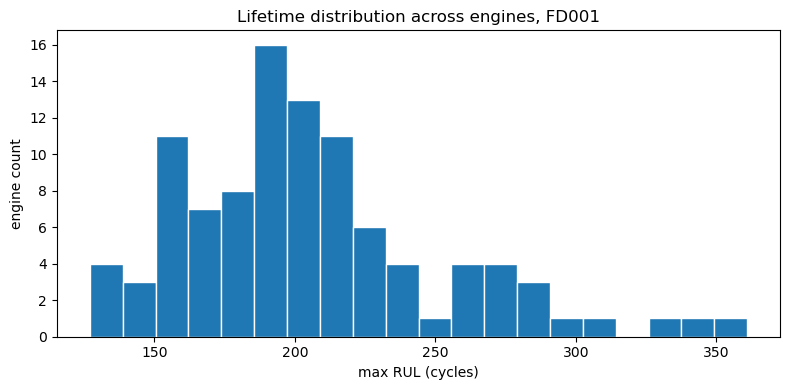

count    100.0
mean     205.3
std       46.3
min      127.0
25%      176.0
50%      198.0
75%      228.2
max      361.0
Name: rul, dtype: float64


In [4]:
# one RUL value per engine (at cycle 1) summarises the full lifetime distribution
engine_max_rul = df.groupby('engine_id')['rul'].max()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(engine_max_rul, bins=20, edgecolor='white')
ax.set_xlabel('max RUL (cycles)')
ax.set_ylabel('engine count')
ax.set_title('Lifetime distribution across engines, FD001')
plt.tight_layout()
plt.show()

print(engine_max_rul.describe().round(1))

## 3. Drop uninformative columns

In [5]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
op_cols = [f'op_setting_{i}' for i in range(1, 4)]

# FD001 is a single operating condition, so op_settings are constant
drop_op = {c: 'single operating condition, no variance' for c in op_cols}

# threshold chosen to catch sensors with negligible spread relative to sensor_2's range
STD_THRESHOLD = 0.05
sensor_stds = df[sensor_cols].std()
drop_sensors = {
    c: f'near-constant (std={sensor_stds[c]:.4f})'
    for c in sensor_cols
    if sensor_stds[c] < STD_THRESHOLD
}

dropped = {**drop_op, **drop_sensors}
surviving_sensors = [c for c in sensor_cols if c not in dropped]

print('Dropped:')
for col, reason in dropped.items():
    print(f'  {col}: {reason}')
print()
print('Surviving sensors:', surviving_sensors)

Dropped:
  op_setting_1: single operating condition, no variance
  op_setting_2: single operating condition, no variance
  op_setting_3: single operating condition, no variance
  sensor_1: near-constant (std=0.0000)
  sensor_5: near-constant (std=0.0000)
  sensor_6: near-constant (std=0.0014)
  sensor_10: near-constant (std=0.0000)
  sensor_15: near-constant (std=0.0375)
  sensor_16: near-constant (std=0.0000)
  sensor_18: near-constant (std=0.0000)
  sensor_19: near-constant (std=0.0000)

Surviving sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']


In [6]:
df = df.drop(columns=list(dropped.keys()))

## 4. Per-engine min-max scaling

In [7]:
# global scaling would conflate sensor level with degradation state;
# scaling within each engine isolates the degradation trajectory
def scale_engine(group):
    scaler = MinMaxScaler()
    group = group.copy()
    group[surviving_sensors] = scaler.fit_transform(group[surviving_sensors])
    return group

df = df.groupby('engine_id', group_keys=False).apply(scale_engine)

/tmp/ipykernel_30064/4123397952.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('engine_id', group_keys=False).apply(scale_engine)


## 5. Save

In [8]:
df.to_parquet('../data/train_FD001_clean.parquet', index=False)
print(f'Saved {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Saved 20631 rows, 16 columns


,engine_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_17,sensor_20,sensor_21,rul
0,1,1,0.044,0.434626,0.180277,0.859155,0.18750,0.463380,0.338462,0.639640,0.131579,0.933895,0.250,0.857143,0.850490,191
1,1,2,0.176,0.510776,0.245506,0.715962,0.12500,0.387638,0.353846,0.825826,0.263158,0.693423,0.250,0.785714,0.858991,190
2,1,3,0.256,0.373204,0.272727,0.835681,0.25000,0.704537,0.184615,0.867868,0.157895,0.752108,0.000,0.726190,0.712253,189
3,1,4,0.256,0.186422,0.212892,0.880282,0.34375,0.580922,0.076923,1.000000,0.289474,0.772344,0.250,0.642857,0.767141,188
4,1,5,0.264,0.188578,0.324602,0.774648,0.18750,0.783494,0.192308,0.798799,0.184211,0.771332,0.375,0.666667,0.823508,187
